In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.data_eng.DataRequest import Requests
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
start = '01/01/2003'
end = '01/03/2026'
codes = ['1389', '1393', '1395', '4390', '11752', '433', '21859', '22707', '24364']
ticker = ['PETR4.SA']
data_req = Requests(codes)
data = data_req.get_data(start, end)
df = data_req.get_dataframe()
df = data_req.y_finance_req(ticker, '2000-01-01', '2026-04-01')


fazendo requisiçao - cod 1389
inicio: 01/01/2003 | fim: 01/03/2026
1389 - requisiçao bem sucedida
Exportando dados para parquet - 1389

fazendo requisiçao - cod 1393
inicio: 01/01/2003 | fim: 01/03/2026
1393 - requisiçao bem sucedida
Exportando dados para parquet - 1393

fazendo requisiçao - cod 1395
inicio: 01/01/2003 | fim: 01/03/2026
1395 - requisiçao bem sucedida
Exportando dados para parquet - 1395

fazendo requisiçao - cod 4390
inicio: 01/01/2003 | fim: 01/03/2026
4390 - requisiçao bem sucedida
Exportando dados para parquet - 4390

fazendo requisiçao - cod 11752
inicio: 01/01/2003 | fim: 01/03/2026
11752 - requisiçao bem sucedida
Exportando dados para parquet - 11752

fazendo requisiçao - cod 433
inicio: 01/01/2003 | fim: 01/03/2026
433 - requisiçao bem sucedida
Exportando dados para parquet - 433

fazendo requisiçao - cod 21859
inicio: 01/01/2003 | fim: 01/03/2026
21859 - requisiçao bem sucedida
Exportando dados para parquet - 21859

fazendo requisiçao - cod 22707
inicio: 01/01/

[*********************100%***********************]  1 of 1 completed

Requisiçao bem sucedida
          data  Produção de derivados de petróleo  \
0   2003-01-01                             1503.0   
1   2003-02-01                             1544.0   
2   2003-03-01                             1512.0   
3   2003-04-01                             1520.0   
4   2003-05-01                             1488.0   
..         ...                                ...   
274 2025-11-01                             3773.0   
275 2025-12-01                             4015.0   
276 2026-01-01                             3953.0   
277 2026-02-01                             4061.0   
278 2026-03-01                                NaN   

     Consumo de derivados de petróleo - gasolina  \
0                                          282.0   
1                                          272.0   
2                                          243.0   
3                                          272.0   
4                                          284.0   
..                         

In [3]:
df

,Produção de derivados de petróleo,Consumo de derivados de petróleo - gasolina,Consumo de derivados de petróleo - Óleo combustível,Selic,Cambio - IPCA,IPCA,Producao Industrial,Balança comercial,IBC-Br,Close_PETR4.SA,Volume_PETR4.SA
data,,,,,,,,,,,
2003-01-01,1503.0,282.0,112.0,1.97,149.36,2.25,86.2,1059.3,70.11723,1.117643,868684800
2003-02-01,1544.0,272.0,112.0,1.83,160.19,1.57,83.6,1022.7,71.30033,1.004256,650976000
2003-03-01,1512.0,243.0,112.0,1.78,152.85,1.23,90.2,1437.3,70.94719,1.091532,690998400
2003-04-01,1520.0,272.0,110.0,1.87,138.14,0.97,89.2,1616.2,70.44574,1.173632,723820800
2003-05-01,1488.0,284.0,106.0,1.97,133.03,0.61,92.9,2434.4,69.74799,1.242087,837443200
...,...,...,...,...,...,...,...,...,...,...,...
2025-11-01,3773.0,589.0,17.0,1.05,122.77,0.18,103.2,5038.2,109.28228,30.394917,862424100
2025-12-01,4015.0,687.0,18.0,1.22,125.67,0.33,93.9,8505.4,109.29356,29.467482,713308800
2026-01-01,3953.0,580.0,17.0,1.16,123.71,0.33,95.2,2907.0,110.22869,37.243122,961223500


tratar os dados nulos pela media ou mediana

verificar distribuiçoes comuns e temporais

verificar sazonalidade 

verificar picos  

criar flags de mudanças de regimes 


self.y_finance_list = []
            for yfinance in ticker:
                data_y = yf.download(yfinance, interval='1mo', start=start_ticker, end=end_ticker)[['Close', 'Volume']]
                data_y = data_y.reset_index()
                data_y['Ticker'] = yfinance
                self.y_finance_list.append(data_y)
            
            
            return self.response_list, self.y_finance_list

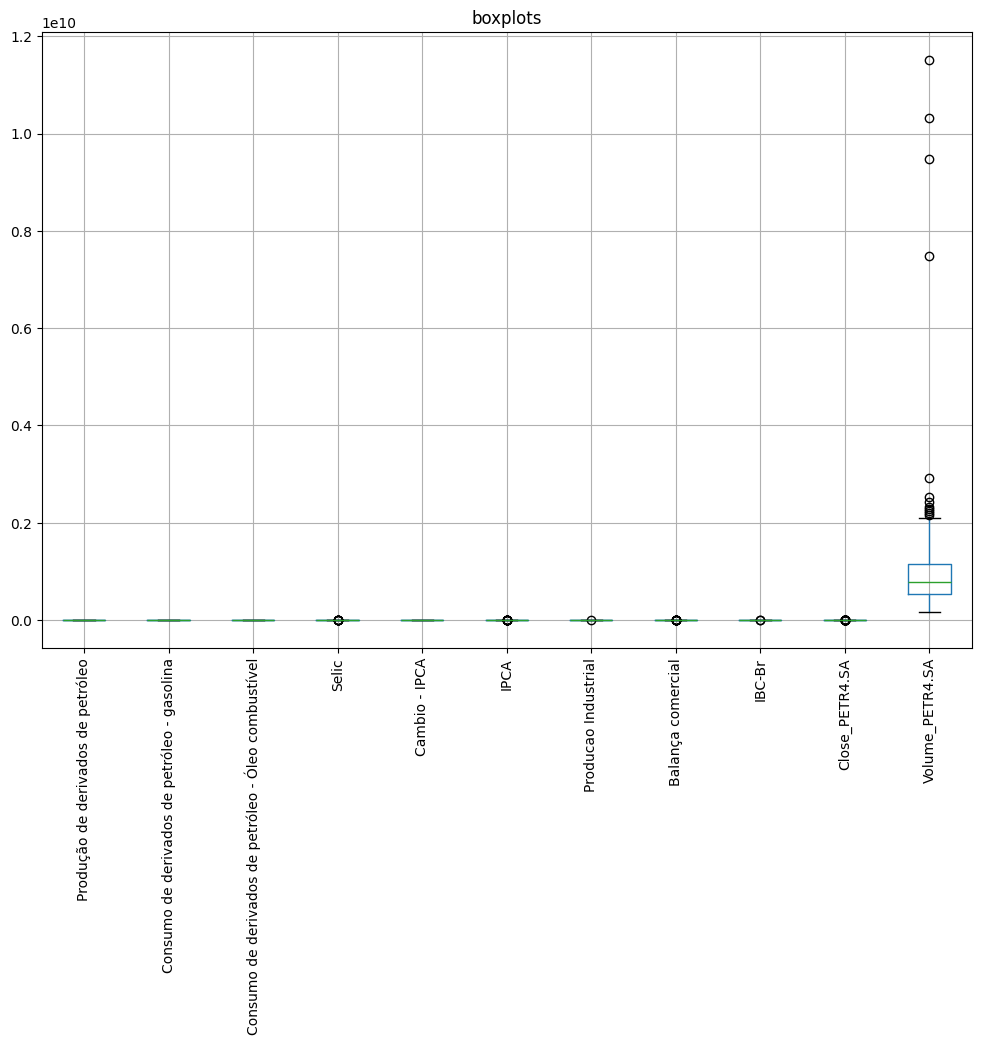

In [4]:
plt.figure(figsize=(12,8))
plt.title('boxplots')
df.boxplot()
plt.xticks(rotation=90)
plt.show()


In [5]:
df.columns

Index(['Produção de derivados de petróleo',
       'Consumo de derivados de petróleo - gasolina',
       'Consumo de derivados de petróleo - Óleo combustível', 'Selic',
       'Cambio - IPCA', 'IPCA', 'Producao Industrial', 'Balança comercial',
       'IBC-Br', 'Close_PETR4.SA', 'Volume_PETR4.SA'],
      dtype='object')

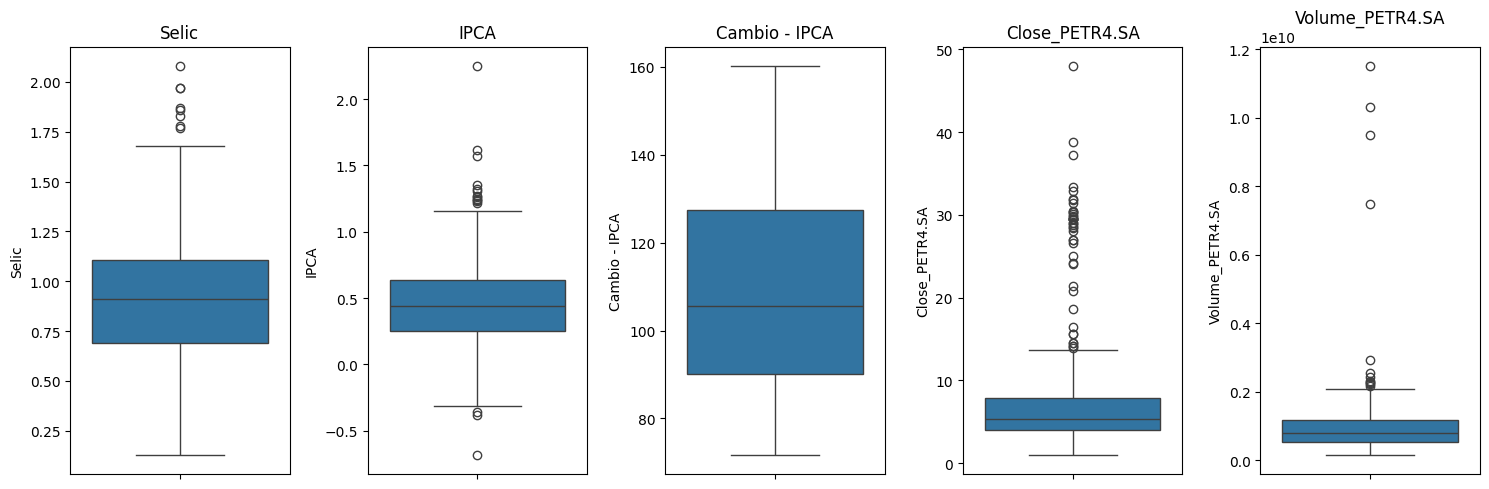

In [6]:
plot_cols = ['Selic', 'IPCA', 'Cambio - IPCA', 'Close_PETR4.SA', 'Volume_PETR4.SA']
fig, axes = plt.subplots(1, len(plot_cols), figsize=(15,5))
for box, ax in zip(plot_cols, axes):
    sns.boxplot(y=df[box], ax=ax)
    ax.set_title(box)
plt.tight_layout()
plt.show()


In [7]:
df.isnull().sum()

Produção de derivados de petróleo                      1
Consumo de derivados de petróleo - gasolina            1
Consumo de derivados de petróleo - Óleo combustível    1
Selic                                                  0
Cambio - IPCA                                          2
IPCA                                                   0
Producao Industrial                                    1
Balança comercial                                      0
IBC-Br                                                 1
Close_PETR4.SA                                         0
Volume_PETR4.SA                                        0
dtype: int64

**Tratando os dados de forma temporal**

 ## Verificando coeficiente de variação 

In [8]:
coef = pd.DataFrame([df.std()/df.mean()]).T
coef

,0
Produção de derivados de petróleo,0.272958
Consumo de derivados de petróleo - gasolina,0.240725
Consumo de derivados de petróleo - Óleo combustível,0.433554
Selic,0.391165
Cambio - IPCA,0.200805
IPCA,0.745825
Producao Industrial,0.103097
Balança comercial,0.840137
IBC-Br,0.106818
Close_PETR4.SA,1.020488


**Produção de derivados de petróleo: 0.518471 -> variaçao alta > 50%**

**Consumo de derivados de petróleo - gasolina: 0.392714 -> variaçao média > >= 30%**

**Consumo de derivados de petróleo - Óleo combustível: 0.570524 -> variaçao alta > 50%**

**Selic: 2.016419 -> variaçao altissima > 200%**

**Cambio - IPCA: 0.220792 -> variaçao baixa/média = aprox 20%**

**Cambio - IPCA: 2.286744 -> variaçao altissima > 200%**

as variaveis como Close e Volume possuem grande variaçoes



colunas que vou usar a média movel para imputaçao: Consumo de derivados de petróleo - gasolina, Cambio - IPCA

In [9]:
def input_mean(data: pd.DataFrame, serie: list, window:int):
    df = data.copy()
    for i in serie:
        df[i] = df[i].fillna(df[i].rolling(window, min_periods=1).mean())
    return df

In [10]:
mean_cols = ['Consumo de derivados de petróleo - gasolina', 'Cambio - IPCA']
df = input_mean(df, mean_cols, 12)
df

,Produção de derivados de petróleo,Consumo de derivados de petróleo - gasolina,Consumo de derivados de petróleo - Óleo combustível,Selic,Cambio - IPCA,IPCA,Producao Industrial,Balança comercial,IBC-Br,Close_PETR4.SA,Volume_PETR4.SA
data,,,,,,,,,,,
2003-01-01,1503.0,282.000000,112.0,1.97,149.360000,2.25,86.2,1059.3,70.11723,1.117643,868684800
2003-02-01,1544.0,272.000000,112.0,1.83,160.190000,1.57,83.6,1022.7,71.30033,1.004256,650976000
2003-03-01,1512.0,243.000000,112.0,1.78,152.850000,1.23,90.2,1437.3,70.94719,1.091532,690998400
2003-04-01,1520.0,272.000000,110.0,1.87,138.140000,0.97,89.2,1616.2,70.44574,1.173632,723820800
2003-05-01,1488.0,284.000000,106.0,1.97,133.030000,0.61,92.9,2434.4,69.74799,1.242087,837443200
...,...,...,...,...,...,...,...,...,...,...,...
2025-11-01,3773.0,589.000000,17.0,1.05,122.770000,0.18,103.2,5038.2,109.28228,30.394917,862424100
2025-12-01,4015.0,687.000000,18.0,1.22,125.670000,0.33,93.9,8505.4,109.29356,29.467482,713308800
2026-01-01,3953.0,580.000000,17.0,1.16,123.710000,0.33,95.2,2907.0,110.22869,37.243122,961223500


In [11]:
df['Produção de derivados de petróleo'] = df['Produção de derivados de petróleo'].fillna(df['Produção de derivados de petróleo'].interpolate('linear', limit_direction='forward'))
df['Consumo de derivados de petróleo - Óleo combustível'] = df['Consumo de derivados de petróleo - Óleo combustível'].fillna(df['Consumo de derivados de petróleo - Óleo combustível'].interpolate('linear', limit_direction='forward'))
df['Producao Industrial'] = df['Producao Industrial'].fillna(df['Producao Industrial'].interpolate(method='linear', limit_direction='forward'))
df['Balança comercial'] = df['Balança comercial'].fillna(df['Balança comercial'].interpolate(method='linear', limit_direction='forward'))
df['IBC-Br'] = df['IBC-Br'].fillna(df['IBC-Br'].interpolate(method='linear', limit_direction='forward'))
df.tail()

,Produção de derivados de petróleo,Consumo de derivados de petróleo - gasolina,Consumo de derivados de petróleo - Óleo combustível,Selic,Cambio - IPCA,IPCA,Producao Industrial,Balança comercial,IBC-Br,Close_PETR4.SA,Volume_PETR4.SA
data,,,,,,,,,,,
2025-11-01,3773.0,589.000000,17.0,1.05,122.770000,0.18,103.2,5038.2,109.28228,30.394917,862424100
2025-12-01,4015.0,687.000000,18.0,1.22,125.670000,0.33,93.9,8505.4,109.29356,29.467482,713308800
2026-01-01,3953.0,580.000000,17.0,1.16,123.710000,0.33,95.2,2907.0,110.22869,37.243122,961223500
2026-02-01,4061.0,617.000000,16.0,1.00,127.121818,0.70,92.8,3337.3,110.89057,38.791634,697767300
2026-03-01,4061.0,596.272727,16.0,1.21,126.730000,0.88,92.8,5619.9,110.89057,48.003780,1452021100


**Exportando Base tratada**

In [12]:
data_path = os.path.join('..', 'data', 'processed', 'dados_temporais_tratados.parquet')
df.to_parquet(data_path)


## Estudos temporais

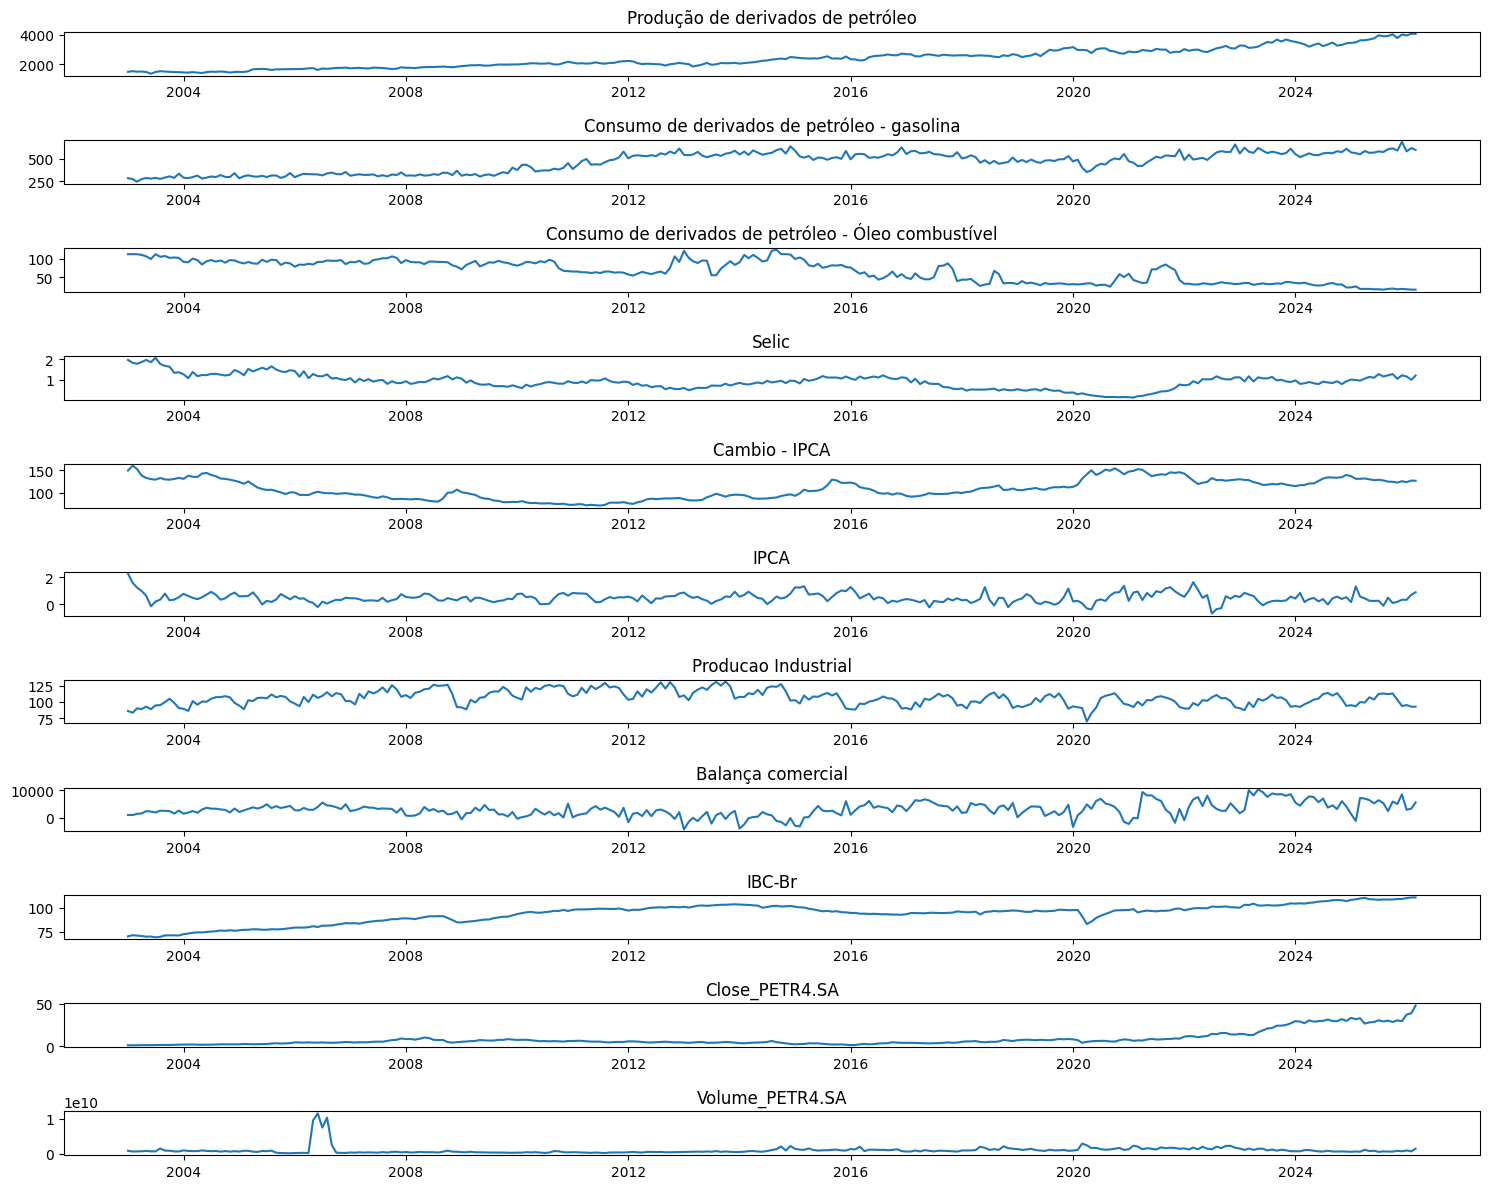

In [13]:
# plotando series 
fig, axes = plt.subplots(len(df.columns), 1, figsize=(15,12))
for plot, ax in zip(df.columns, axes):
    ax.plot(df[plot])
    ax.set_title(plot)
plt.tight_layout()
plt.show()


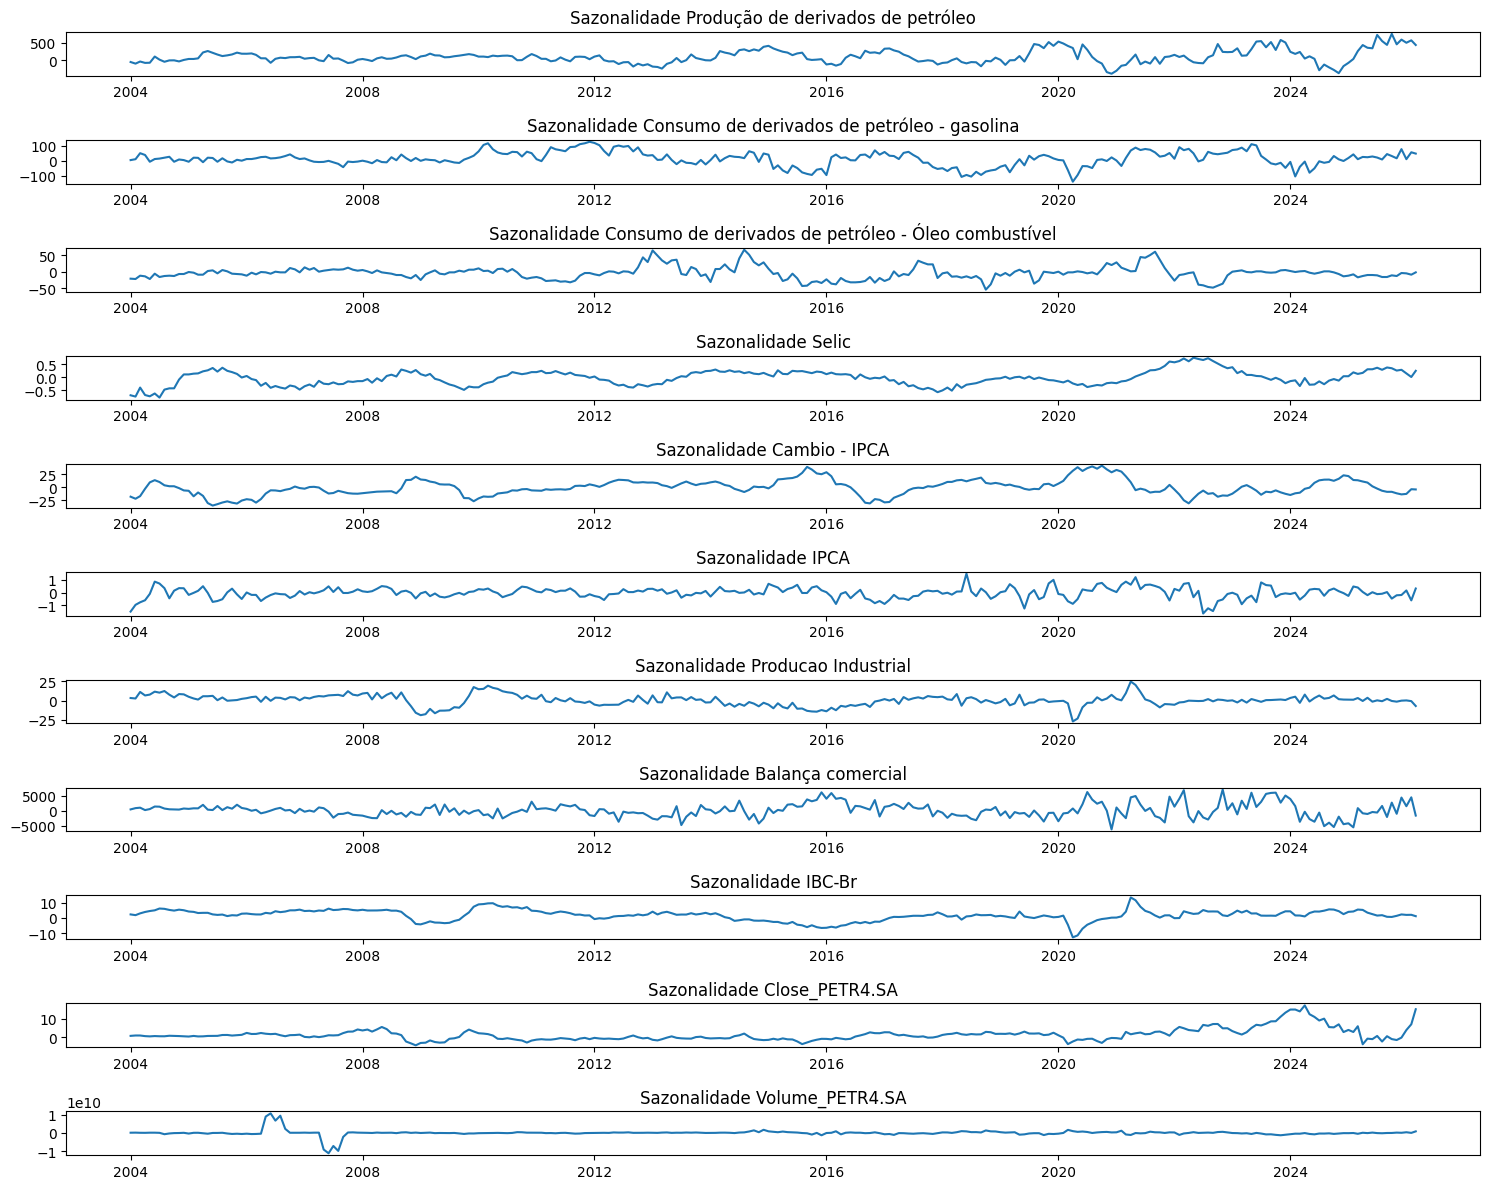

In [14]:
fig, axes = plt.subplots(len(df.columns), 1, figsize=(15,12))
for sazo, ax in zip(df.columns, axes):
    ax.plot(df[sazo].diff(12))
    ax.set_title(f'Sazonalidade {sazo}')
plt.tight_layout()
plt.show()


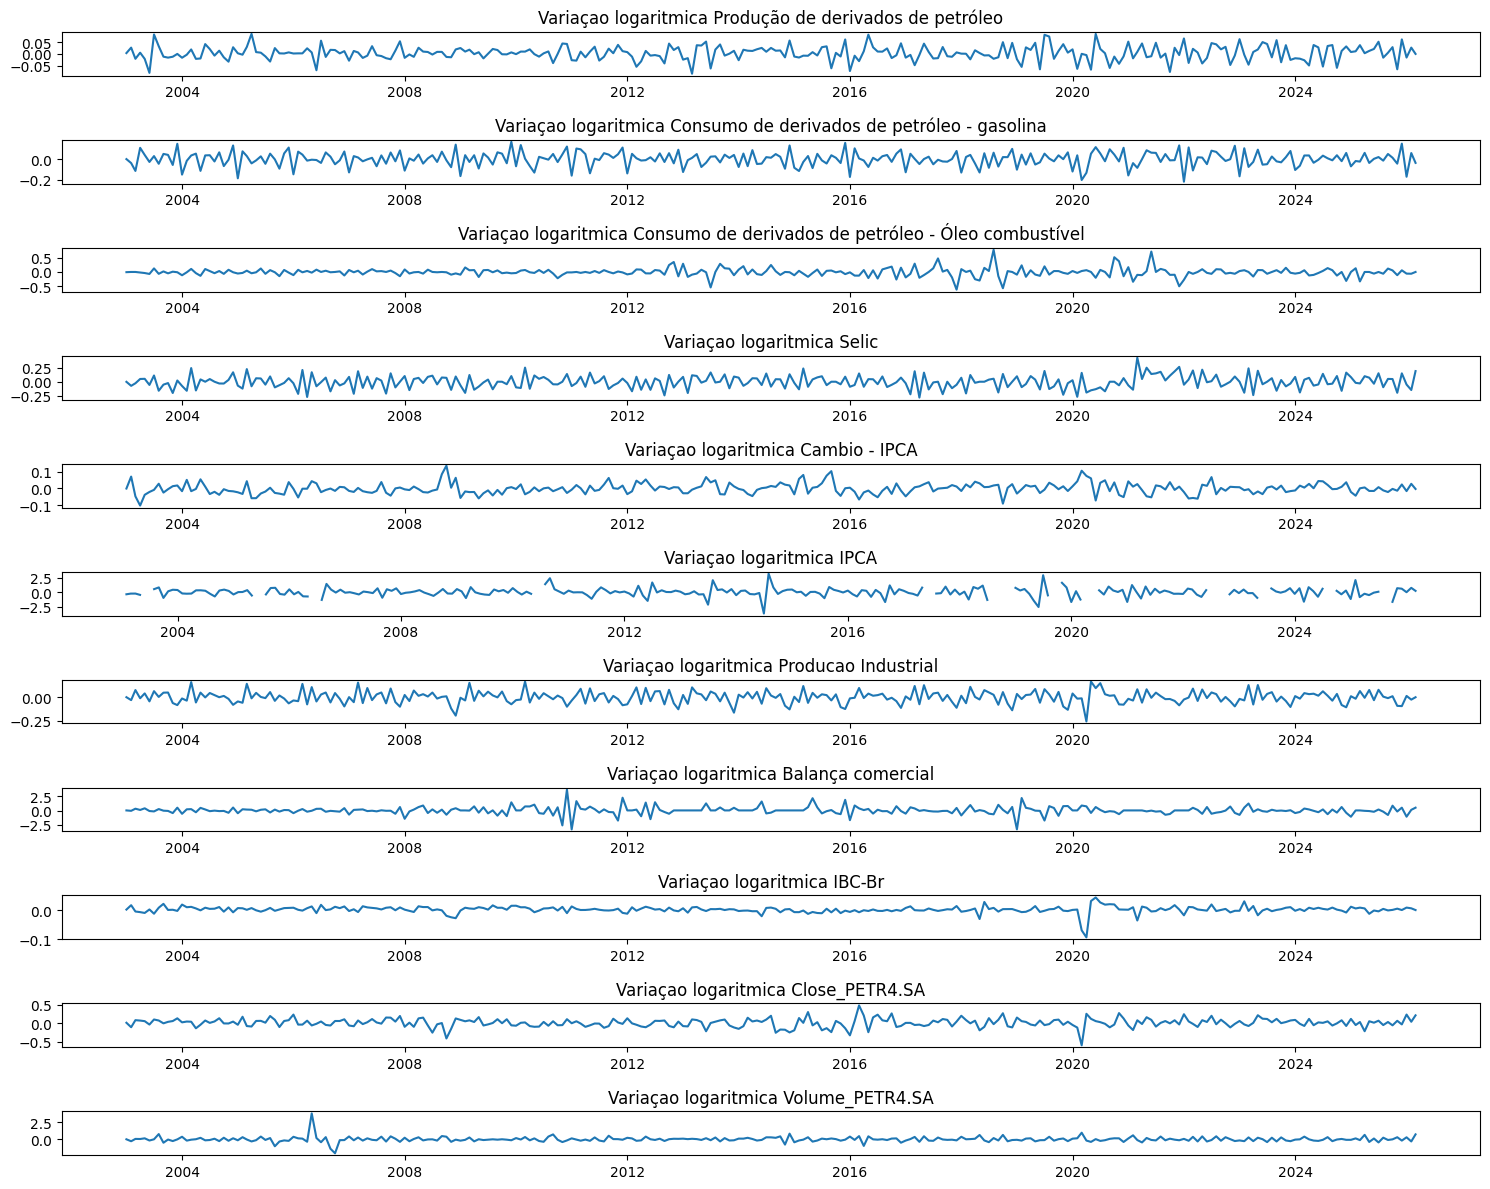

In [15]:
# variaçao logaritmica 
fig, axes = plt.subplots(len(df.columns), 1, figsize=(15,12))
for log, ax in zip(df.columns, axes):
    log_value = np.log(df[log]).diff()
    log_value = log_value.fillna(log_value.mean())
    ax.plot(log_value)
    ax.set_title(f'Variaçao logaritmica {log}')
plt.tight_layout()
plt.show()

média móvel e volatidade

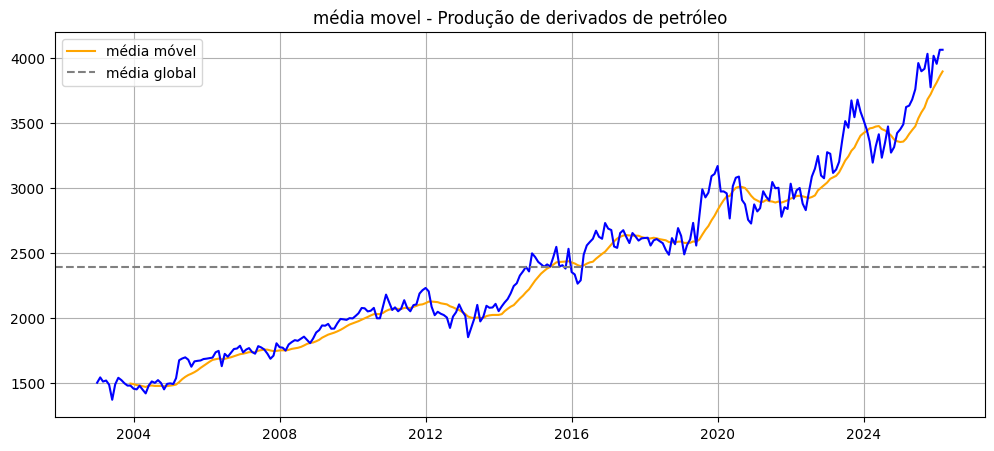

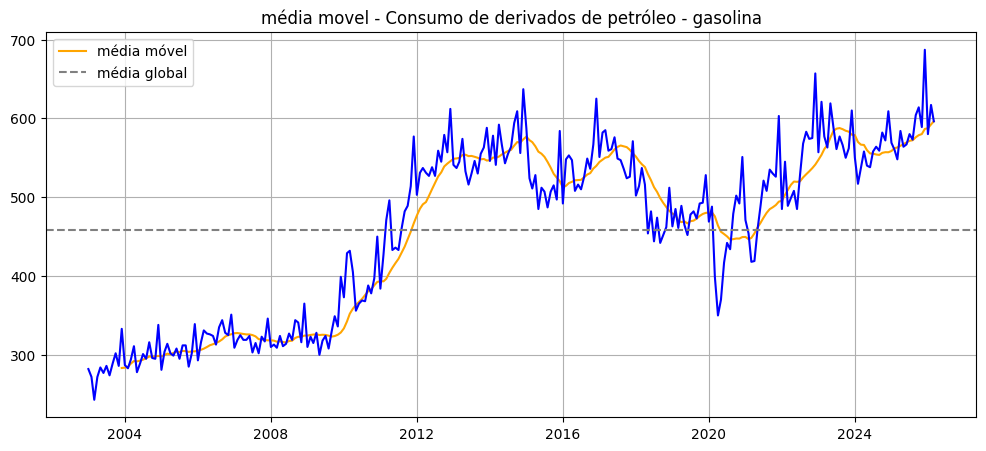

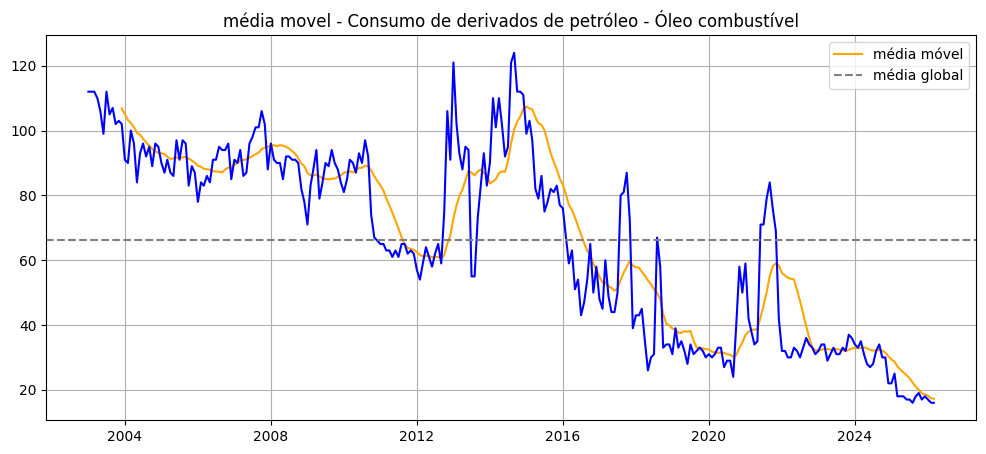

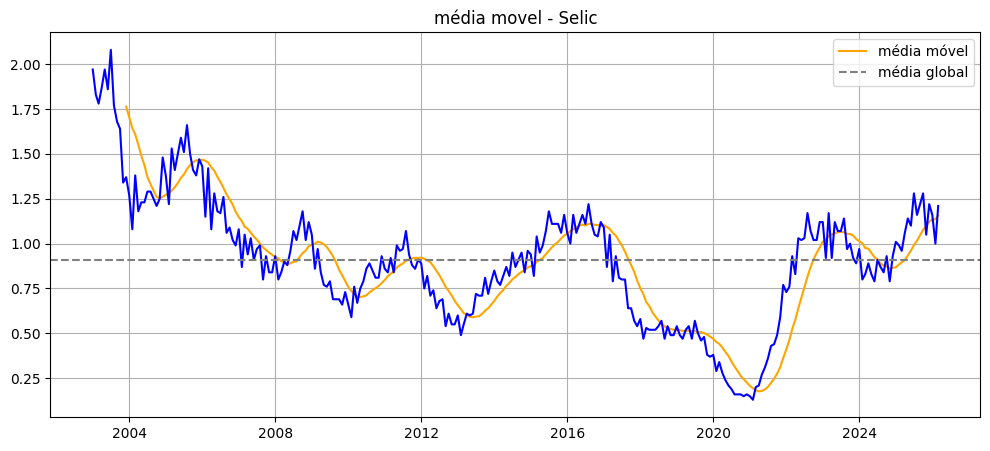

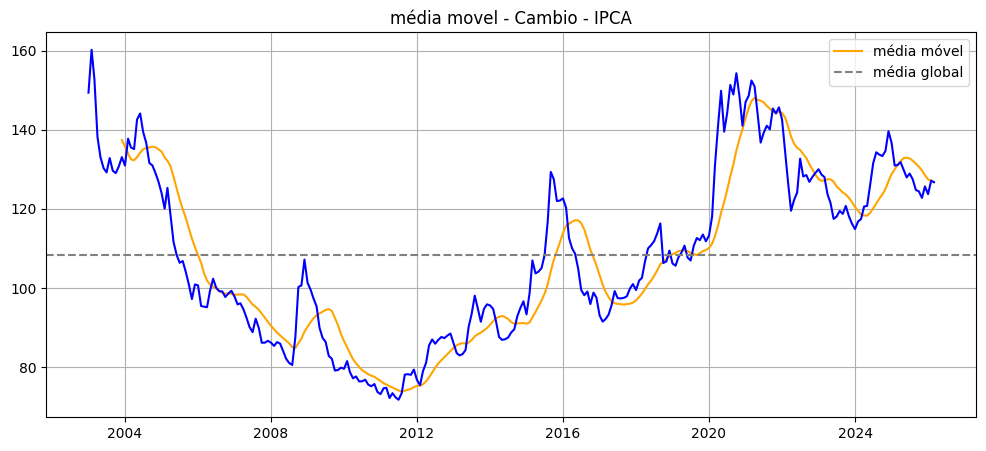

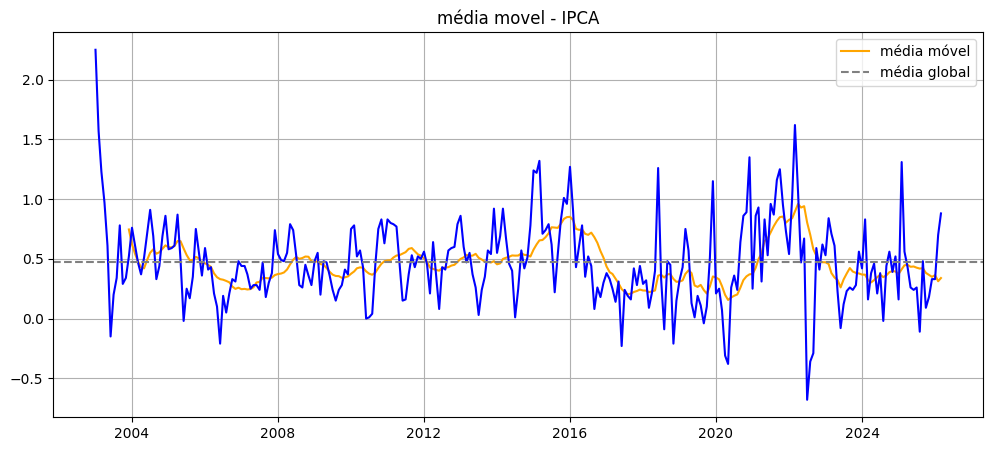

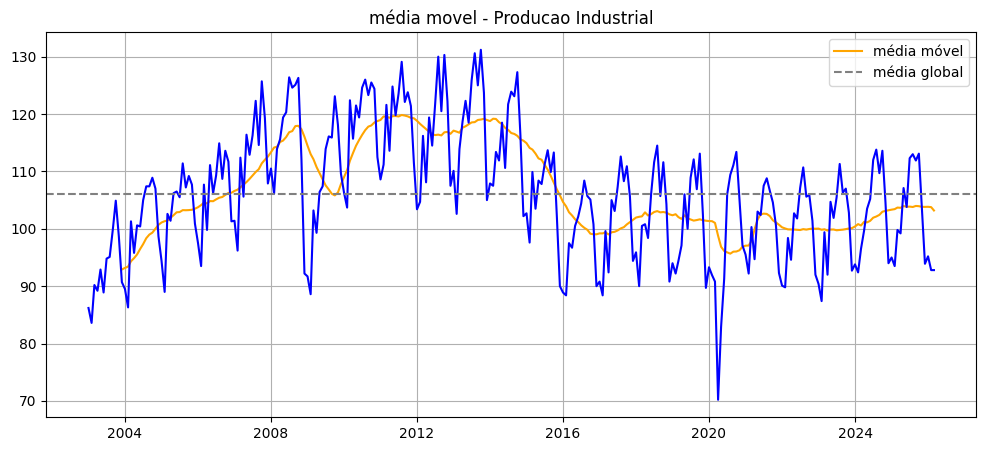

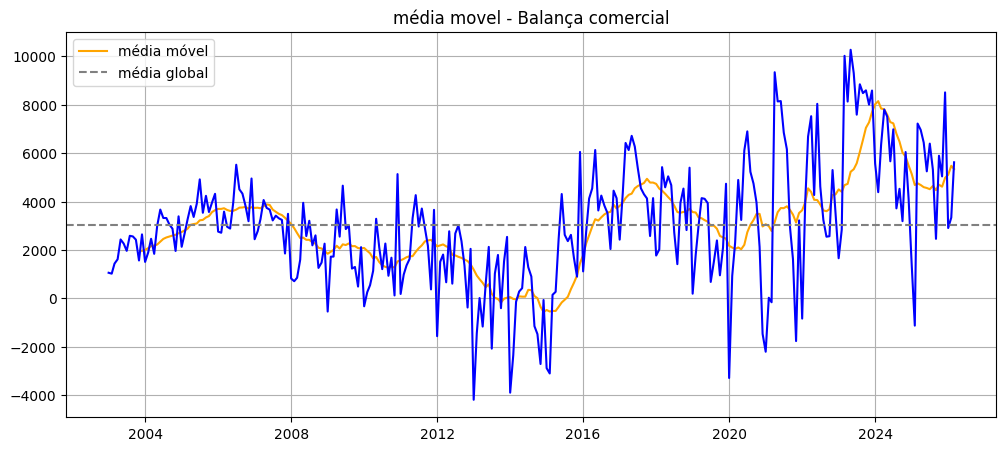

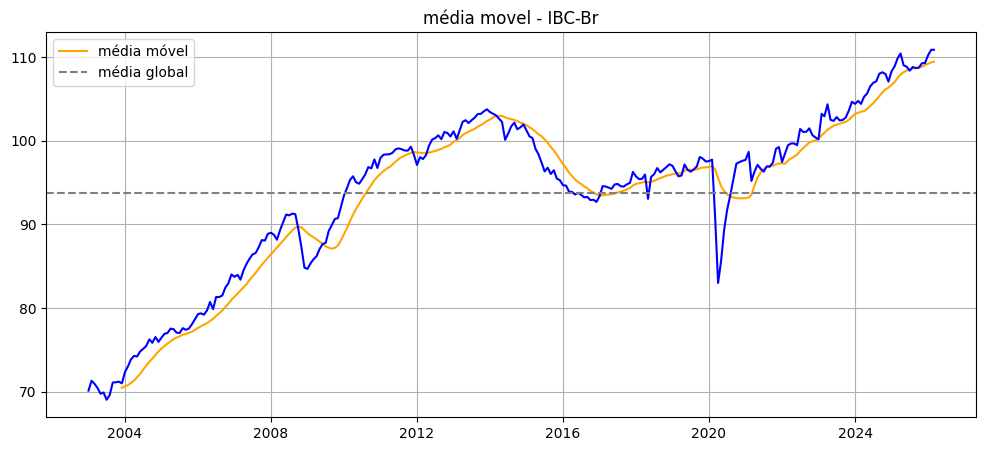

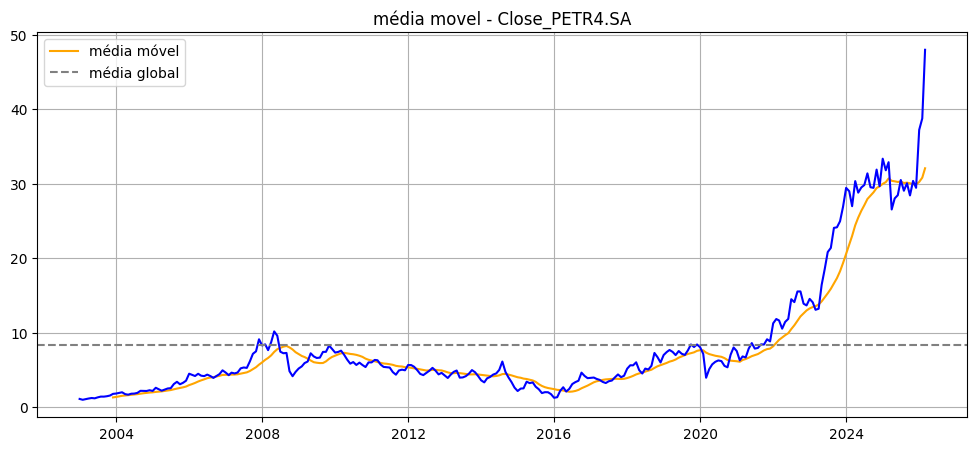

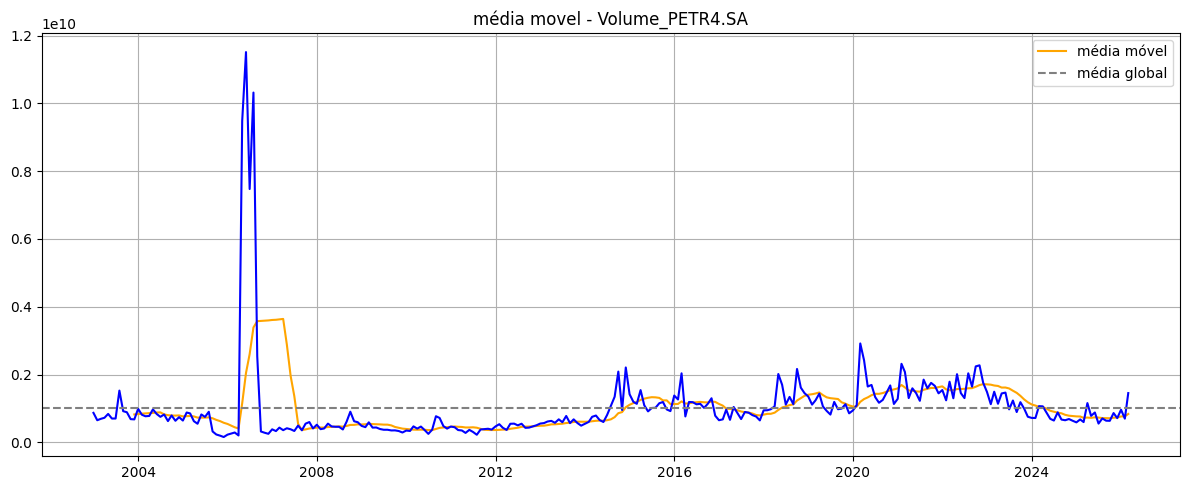

In [16]:
for mean_ in df.columns:
    plt.figure(figsize=(12,5))
    plt.title(f'média movel - {mean_}')
    mean = df[mean_].rolling(12).mean()
    plt.plot(mean, label='média móvel', color='orange')
    plt.plot(df[mean_], color='blue')
    plt.axhline(df[mean_].mean(), linestyle='--', color='gray', label='média global')
    plt.grid()
    plt.legend()
plt.tight_layout()
plt.show()
    

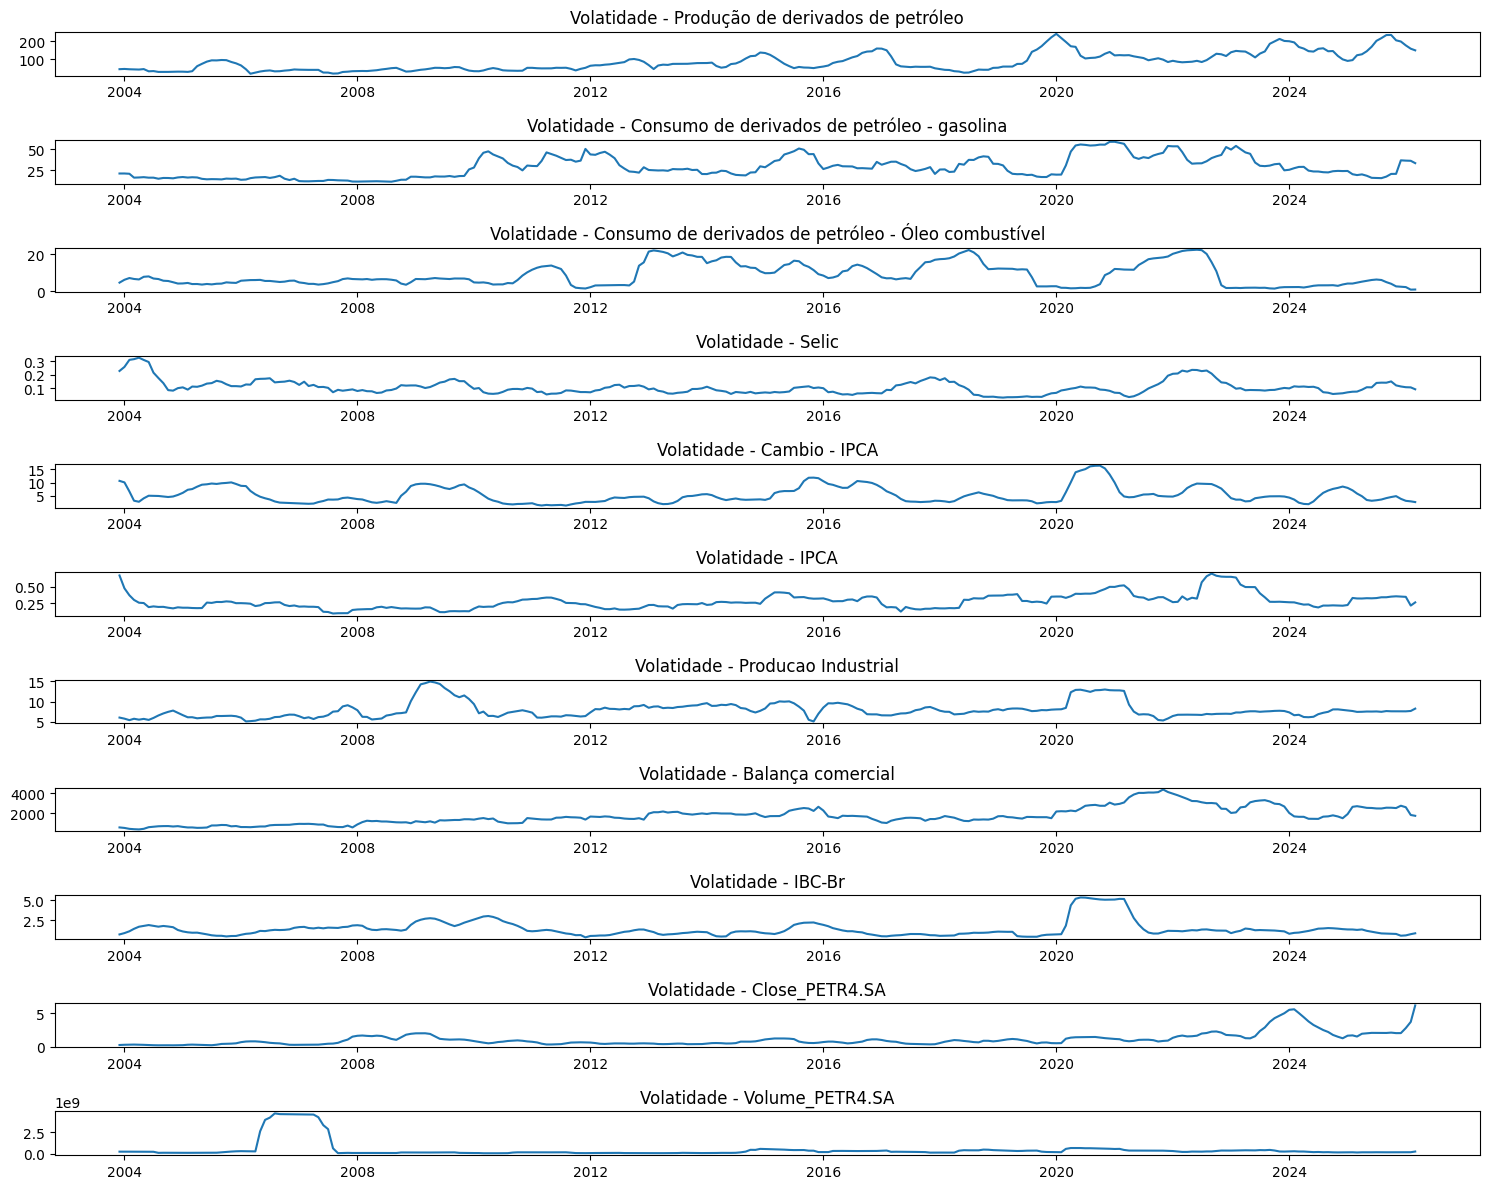

In [17]:
fig, axes = plt.subplots(len(df.columns),1, figsize=(15,12))
for vol, ax in zip(df.columns, axes):
    ax.plot(df[vol].rolling(12).std())
    ax.set_title(f'Volatidade - {vol}')
fig.tight_layout()
fig.show()

Percentual de mudança - Trimestral 

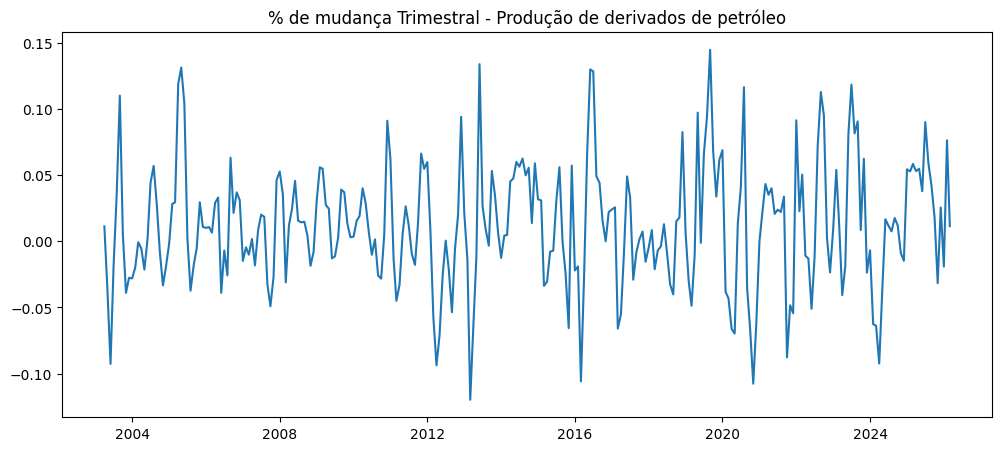

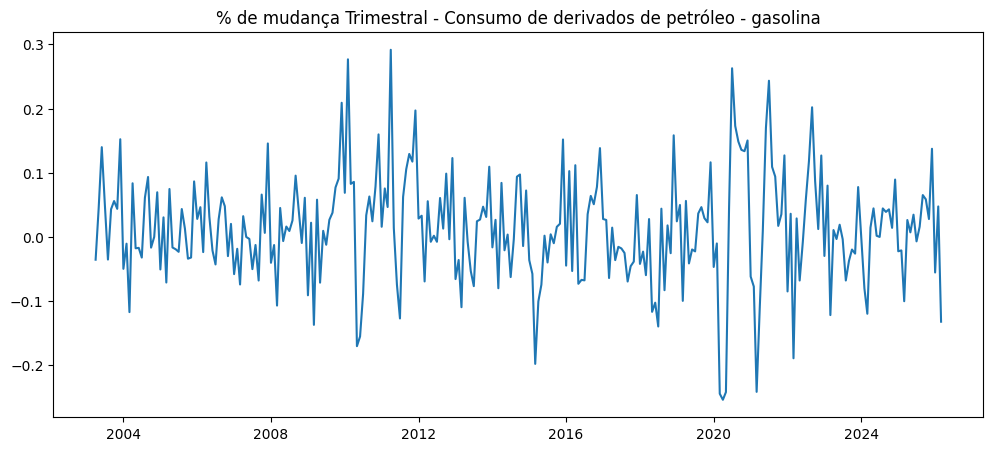

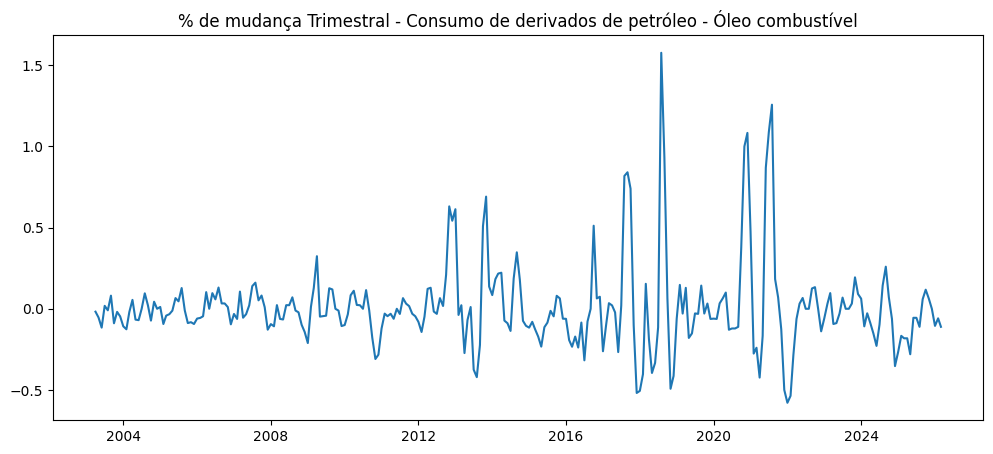

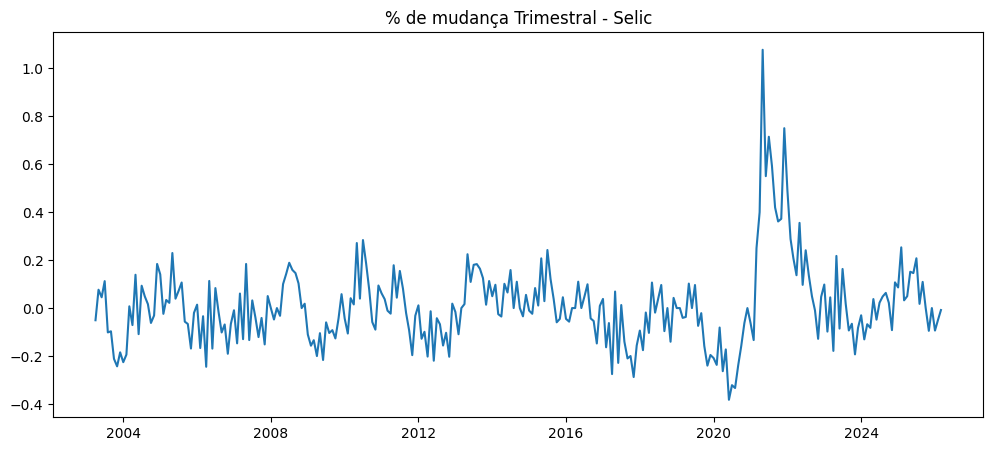

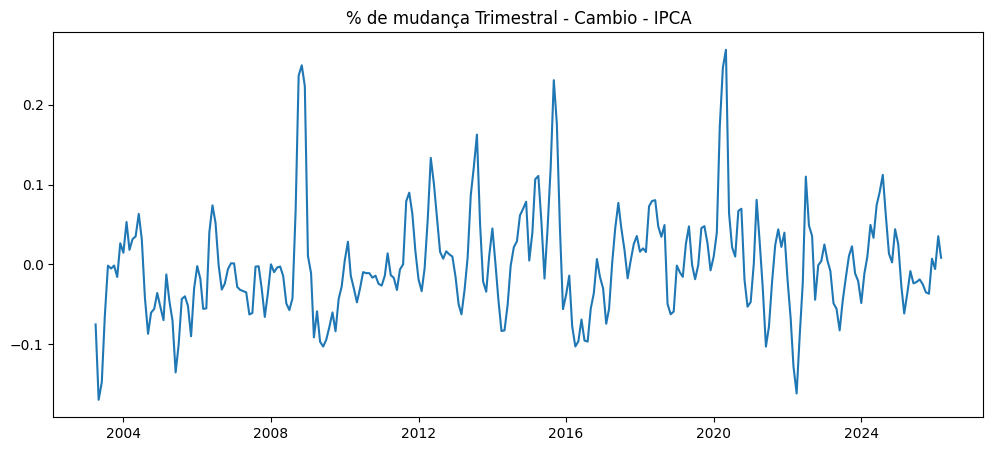

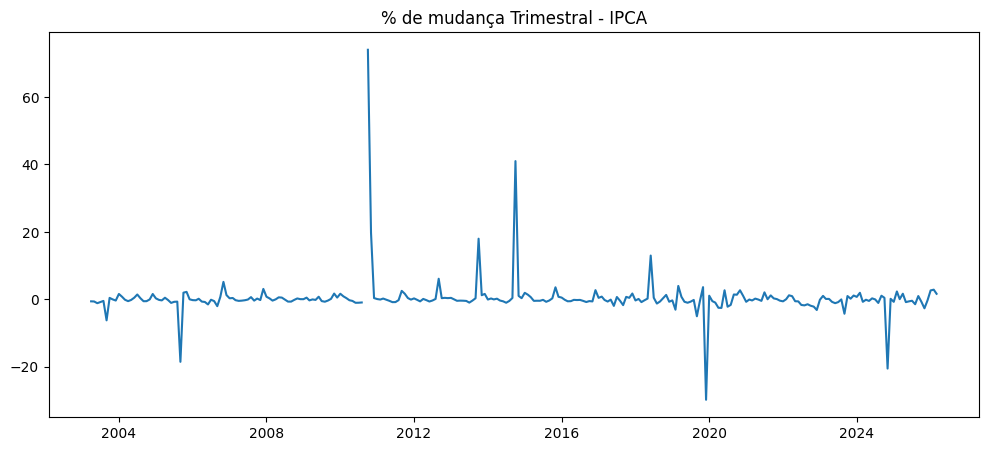

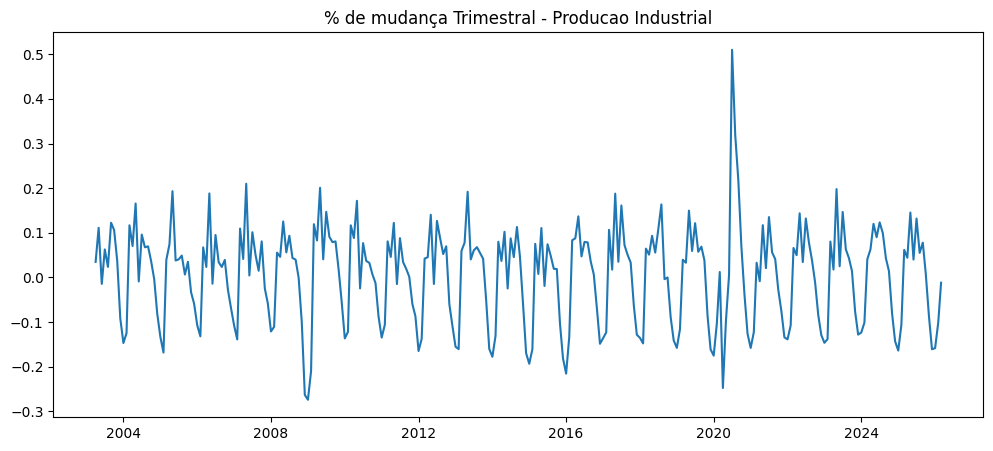

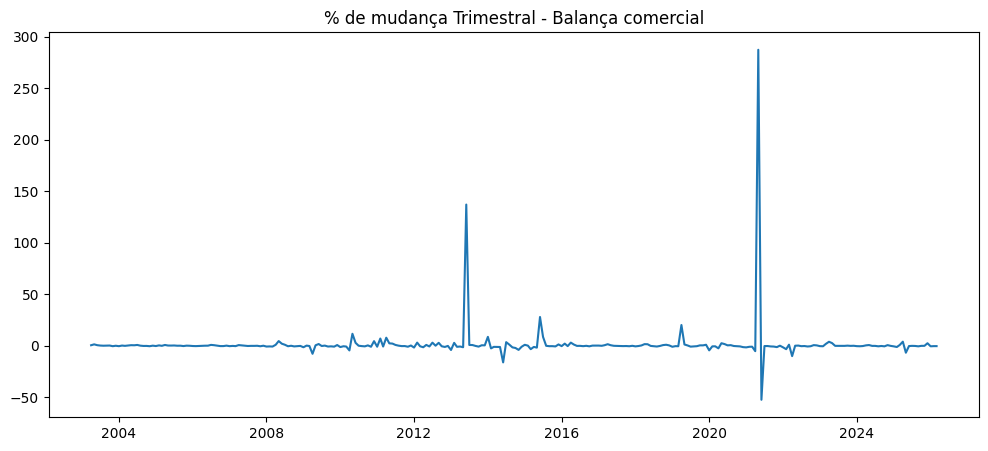

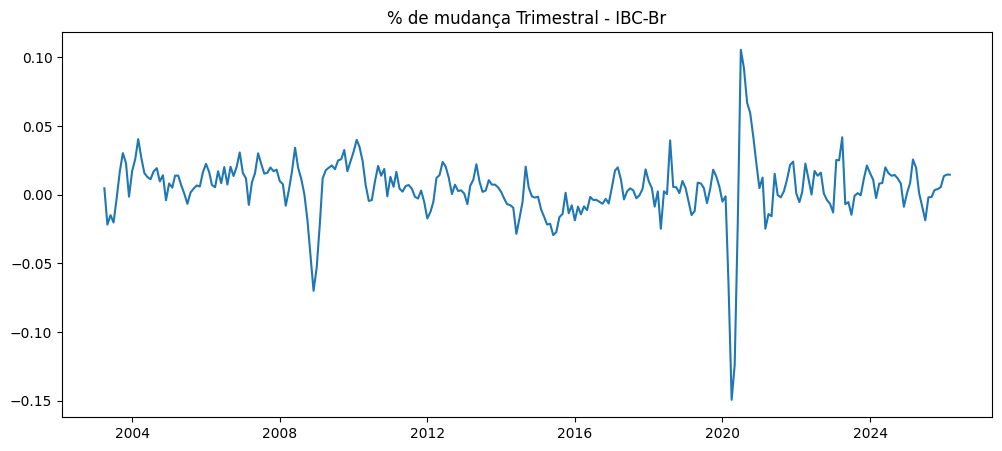

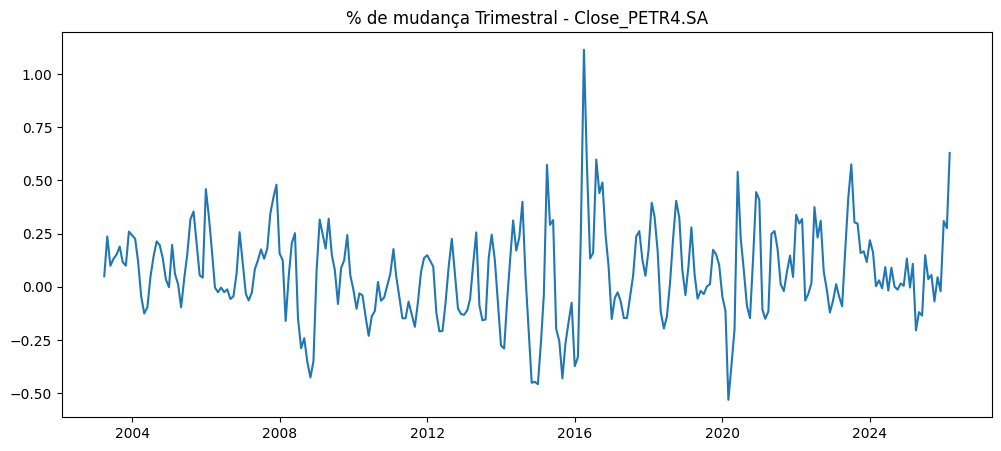

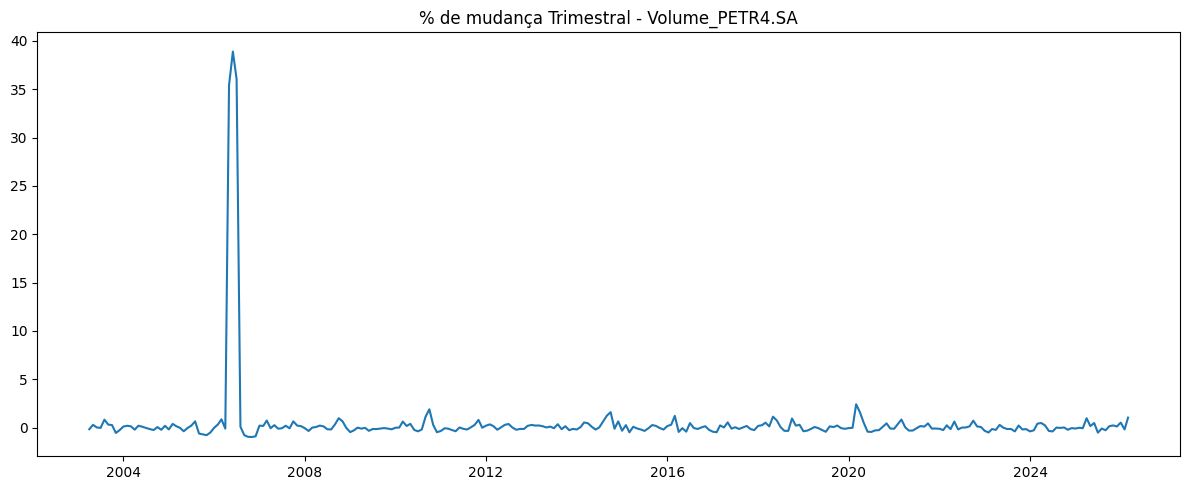

In [18]:
for pct in df.columns:
    plt.figure(figsize=(12,5))
    plt.title(f'% de mudança Trimestral - {pct}')
    plt.plot(df[pct].pct_change(3))
plt.tight_layout()
plt.show()
    

**Cluster**

In [19]:
# separaçao dos fatores para o cluster
df_cluster = pd.DataFrame({
    'feature': df.columns,
    'volatidade':df.rolling(12).std().mean(),
    'pct_change': df.pct_change(3).mean().replace([np.inf, -np.inf], np.nan).fillna(0)
})
df_cluster = df_cluster.reset_index(drop=True).set_index('feature')
df_cluster


,volatidade,pct_change
feature,,
Produção de derivados de petróleo,8.452596e+01,0.011688
Consumo de derivados de petróleo - gasolina,2.818114e+01,0.012403
Consumo de derivados de petróleo - Óleo combustível,8.724279e+00,0.008341
Selic,1.051335e-01,0.007403
Cambio - IPCA,5.421080e+00,-0.000106
IPCA,2.760933e-01,0.000000
Producao Industrial,7.881003e+00,0.006678
Balança comercial,1.735915e+03,1.514452
IBC-Br,1.425411e+00,0.005114


**Teste do cotovelo**

CLUSTER - MinMaxScaler

kluster: 2 - inertia: 0.8861860813640485 - davies bouldin score: 0.17527386648602417 - silhouette_score: 0.7409699060497867
kluster: 3 - inertia: 0.001275042736789136 - davies bouldin score: 0.007226163022803178 - silhouette_score: 0.8089646277948382
kluster: 4 - inertia: 6.70416692495113e-05 - davies bouldin score: 0.03320341550272121 - silhouette_score: 0.654436653267969
kluster: 5 - inertia: 1.8028794890597362e-05 - davies bouldin score: 0.11758435880618893 - silhouette_score: 0.4865755503489082
kluster: 6 - inertia: 2.5417779607641563e-06 - davies bouldin score: 0.11509883529171423 - silhouette_score: 0.5618665594806989
kluster: 7 - inertia: 7.198915672041772e-07 - davies bouldin score: 0.11277044734800658 - silhouette_score: 0.4650162047907718
kluster: 8 - inertia: 2.284792802525043e-07 - davies bouldin score: 0.11944732902907398 - silhouette_score: 0.3939137935675854
kluster: 9 - inertia: 1.1393514938433218e-07 - davies bouldin score: 0.04775486519325311 -

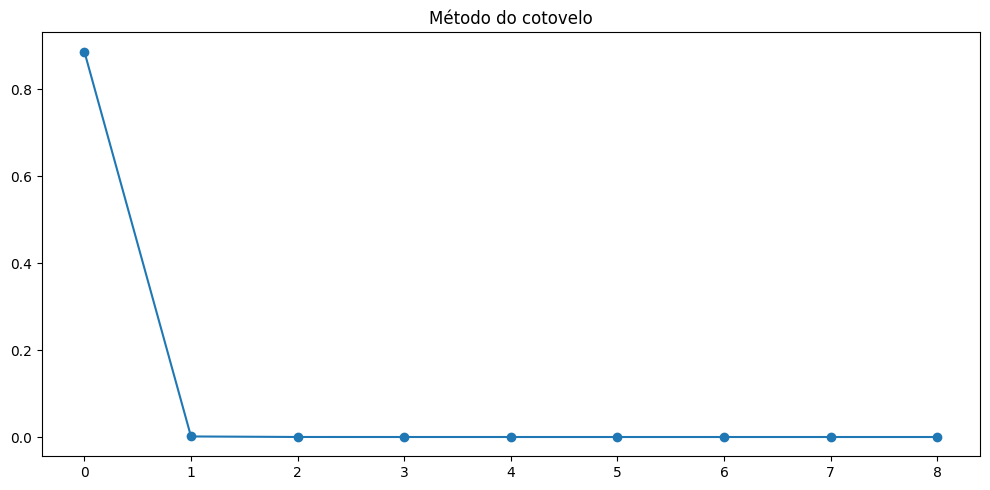

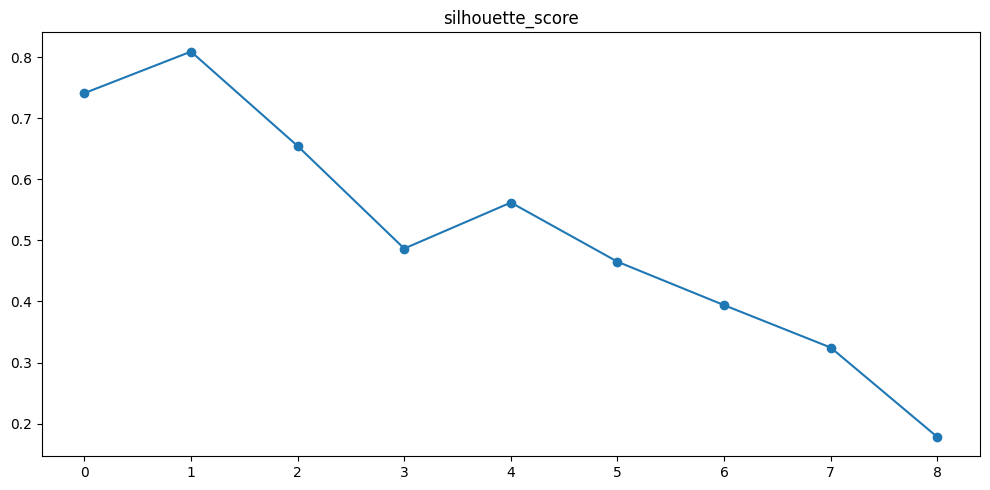

In [20]:
print('CLUSTER - MinMaxScaler')
print('=========='*50)
print()
min_max_scaler = MinMaxScaler()
df_preprocessing = min_max_scaler.fit_transform(df_cluster)
inertia = []
silhouette = []
for i in range(2, 11):
    kmeans_ = KMeans(i, max_iter=1000, random_state=42).fit(df_preprocessing)
    sil_score = silhouette_score(df_preprocessing, kmeans_.labels_)
    print(f'kluster: {i} - inertia: {kmeans_.inertia_} - davies bouldin score: {davies_bouldin_score(df_preprocessing, kmeans_.labels_)} - silhouette_score: {sil_score}')
    inertia.append(kmeans_.inertia_)
    silhouette.append(sil_score)
    
print('=========='*50)

plt.figure(figsize=(10,5))
plt.title('Método do cotovelo')
plt.plot(inertia, marker='o')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.title('silhouette_score')
plt.plot(silhouette, marker='o')
plt.tight_layout()
plt.show()



In [21]:
kmeans_final = KMeans( n_clusters=3, max_iter=1000, random_state=42).fit(df_preprocessing)
fig = px.scatter(df_cluster, y='pct_change', x='volatidade',color=kmeans_final.labels_, hover_data='pct_change')
fig.update_layout(width=1200,height=800, autosize=False)
fig.update_traces(marker=dict( colorscale='Viridis', showscale=True))
fig.show()

In [22]:
df_cluster['cluster'] = kmeans_final.labels_
df_cluster

,volatidade,pct_change,cluster
feature,,,
Produção de derivados de petróleo,8.452596e+01,0.011688,0
Consumo de derivados de petróleo - gasolina,2.818114e+01,0.012403,0
Consumo de derivados de petróleo - Óleo combustível,8.724279e+00,0.008341,0
Selic,1.051335e-01,0.007403,0
Cambio - IPCA,5.421080e+00,-0.000106,0
IPCA,2.760933e-01,0.000000,0
Producao Industrial,7.881003e+00,0.006678,0
Balança comercial,1.735915e+03,1.514452,2
IBC-Br,1.425411e+00,0.005114,0


# Interpretação dos Clusters 

- cluster 0 = Baixa mudança percentual (pct_change) e baixa volatilidade 

- cluster 1 = Alta volatilidade e mudança percentual média 

- cluster 2 = alta volatilidade e baixa mundança percentual 

# Matriz de Correlação 

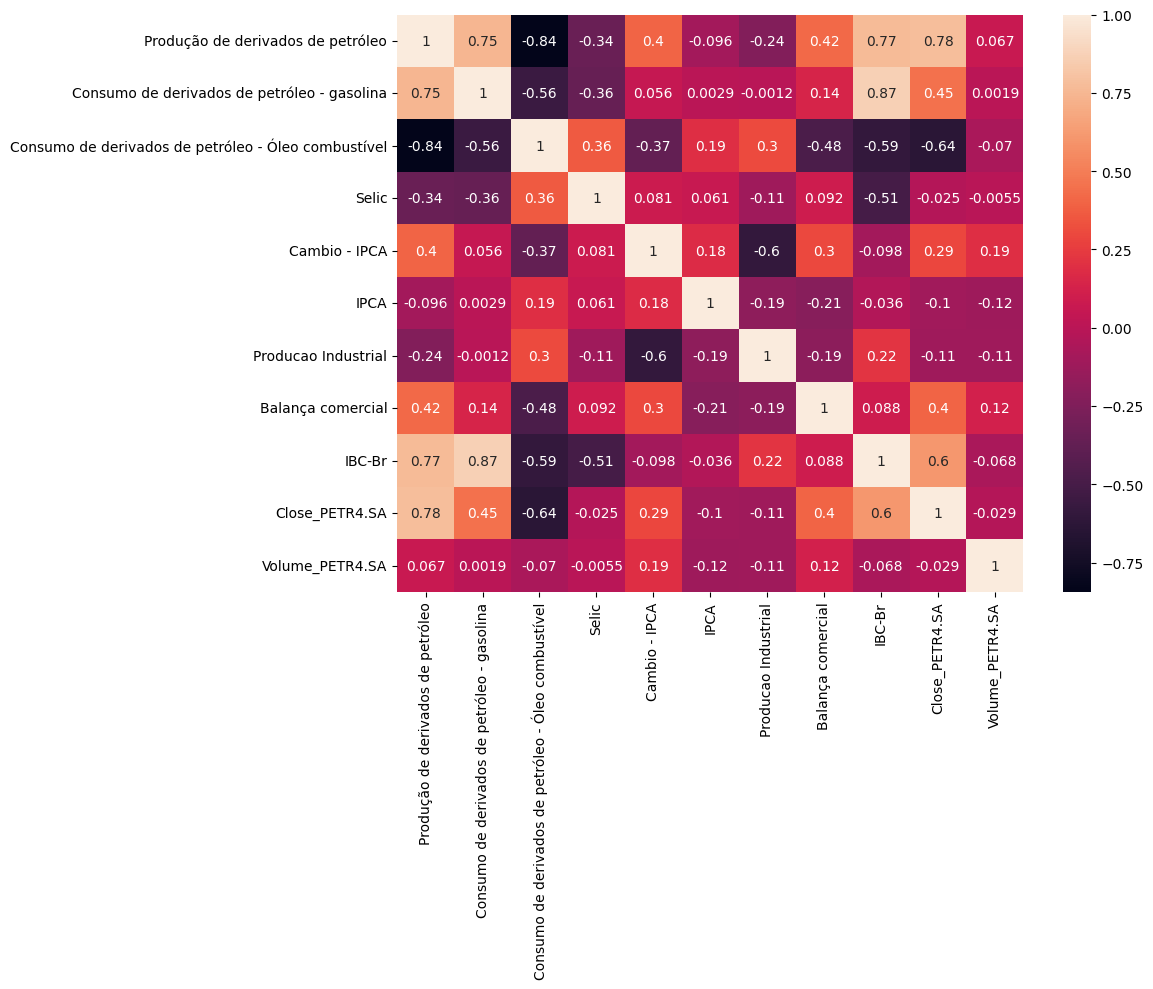

In [23]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True)
plt.tight_layout()
plt.show()

In [24]:
df.columns

Index(['Produção de derivados de petróleo',
       'Consumo de derivados de petróleo - gasolina',
       'Consumo de derivados de petróleo - Óleo combustível', 'Selic',
       'Cambio - IPCA', 'IPCA', 'Producao Industrial', 'Balança comercial',
       'IBC-Br', 'Close_PETR4.SA', 'Volume_PETR4.SA'],
      dtype='object')

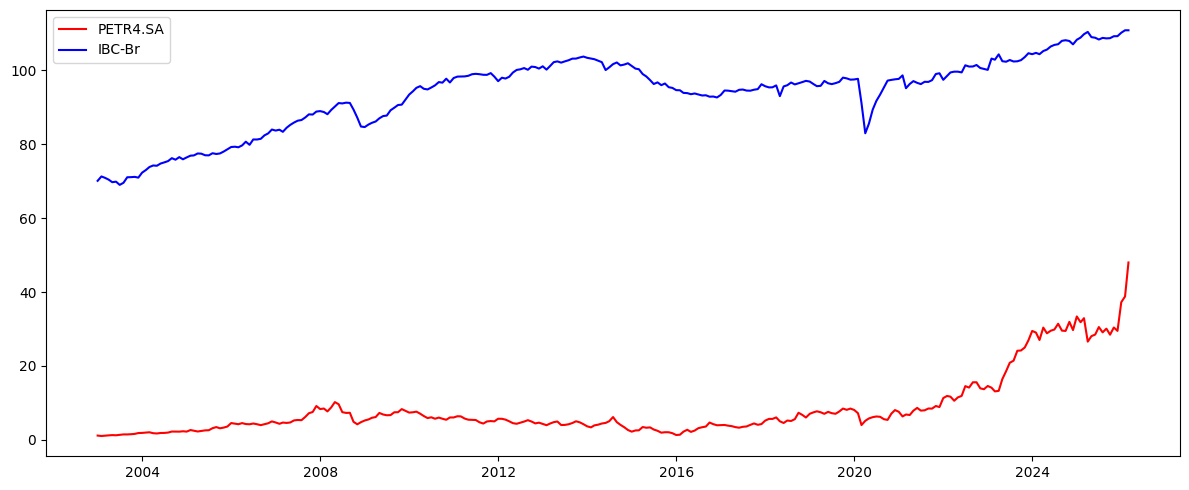

In [25]:
plt.figure(figsize=(12,5))
plt.plot(df['Close_PETR4.SA'], color='red', label='PETR4.SA')
plt.plot(df['IBC-Br'], color='blue', label='IBC-Br')
plt.legend()
plt.tight_layout()
plt.show()

# Definindo Choque

In [26]:
df.columns

Index(['Produção de derivados de petróleo',
       'Consumo de derivados de petróleo - gasolina',
       'Consumo de derivados de petróleo - Óleo combustível', 'Selic',
       'Cambio - IPCA', 'IPCA', 'Producao Industrial', 'Balança comercial',
       'IBC-Br', 'Close_PETR4.SA', 'Volume_PETR4.SA'],
      dtype='object')

In [27]:
brent = data_req.get_ibov('^BVSP', '2000-01-01', '2026-04-01')
df['Close_IBOV'] = brent['Close_IBOV']
df.isnull().sum()

[*********************100%***********************]  1 of 1 completed


Produção de derivados de petróleo                      0
Consumo de derivados de petróleo - gasolina            0
Consumo de derivados de petróleo - Óleo combustível    0
Selic                                                  0
Cambio - IPCA                                          0
IPCA                                                   0
Producao Industrial                                    0
Balança comercial                                      0
IBC-Br                                                 0
Close_PETR4.SA                                         0
Volume_PETR4.SA                                        0
Close_IBOV                                             0
dtype: int64

In [28]:
ibov_zscore = stats.zscore(df['Close_IBOV'])
ibov_zscore = pd.DataFrame(ibov_zscore)
ibov_zscore

,Close_IBOV
data,
2003-01-01,-1.681117
2003-02-01,-1.699368
2003-03-01,-1.671909
2003-04-01,-1.636431
2003-05-01,-1.612512
...,...
2025-11-01,2.415018
2025-12-01,2.471788
2026-01-01,3.031439


média positiva z_score = Close_IBOV    1.101343
dtype: float64


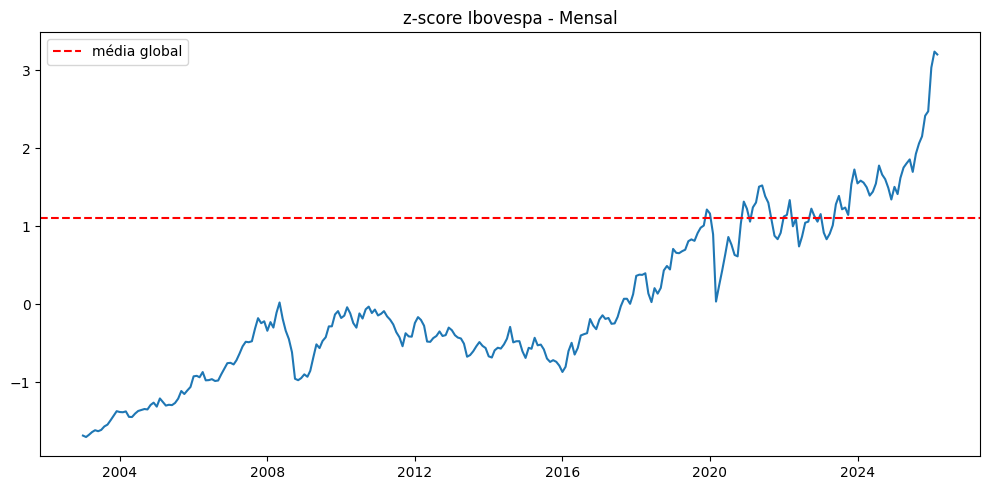

In [29]:
mean_ibov = ibov_zscore[ibov_zscore['Close_IBOV']>0].mean()
print(f'média positiva z_score = {mean_ibov}')
plt.figure(figsize=(10,5))
plt.title('z-score Ibovespa - Mensal')
plt.plot(ibov_zscore)
plt.axhline(mean_ibov.values, linestyle='--', color='red', label='média global')
plt.legend()
plt.tight_layout()
plt.show()



# Calculando coeficiente beta

In [30]:
# calculo de covariancia e variancia dos retornos dentro de uma janela de 12 meses
returns = df[['Close_PETR4.SA', 'Close_IBOV']].pct_change().dropna()
cov = returns['Close_PETR4.SA'].rolling(12).cov(returns['Close_IBOV'])
var = returns['Close_IBOV'].rolling(12).var()
df['BETA'] = cov/var

<Axes: xlabel='data'>

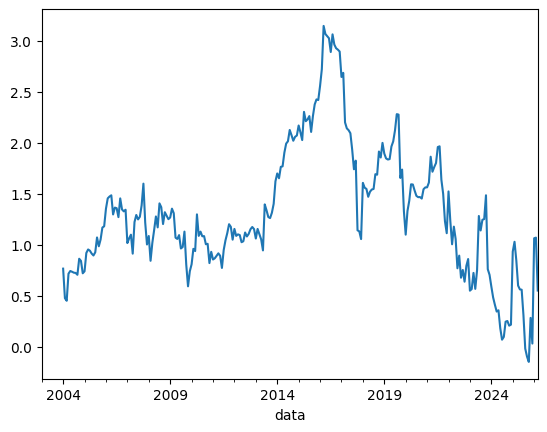

In [31]:
df['BETA'].plot()

In [32]:
returns

,Close_PETR4.SA,Close_IBOV
data,,
2003-02-01,-0.101452,-0.060324
2003-03-01,0.086906,0.096586
2003-04-01,0.075216,0.113802
2003-05-01,0.058328,0.068886
2003-06-01,-0.034091,-0.033453
...,...,...
2025-11-01,0.068571,0.063742
2025-12-01,-0.030513,0.012906
2026-01-01,0.263872,0.125611


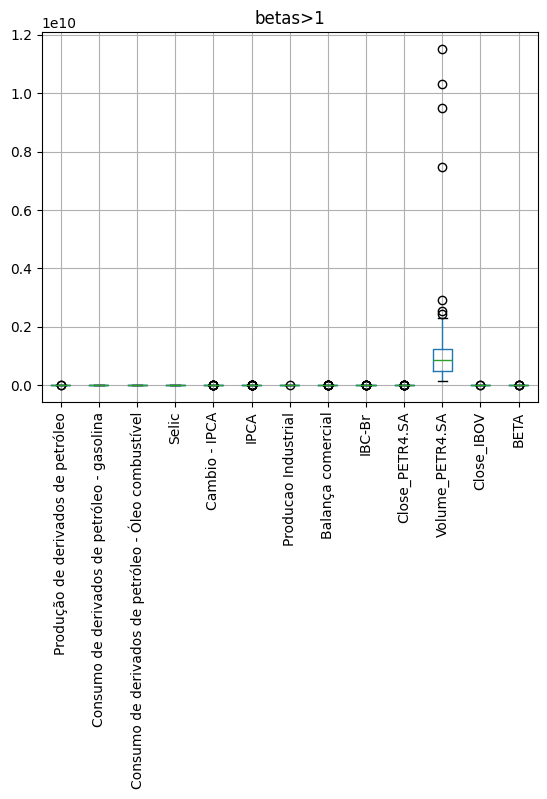

In [33]:
plt.title('betas>1')
df[df['BETA']>1].boxplot()
plt.xticks(rotation=90)
plt.show()

# Choque

In [34]:
# definindo choque por z_score
def shock(serie:pd.Series):
    z_score = (serie-serie.rolling(12).mean())/serie.rolling(12).std()
    print(f'z_score médio: {z_score.mean()}')
    print(f'z_score maximo: {z_score.max()}')
    print(f'z_score minimo: {z_score.min()}')
    
    plt.figure(figsize=(10,5))
    plt.title('z_score ao longo do tempo')
    plt.plot(z_score)
    plt.axhline(z_score.mean(), color='red', label='media',linestyle='--')
    plt.axhline(z_score.min(), color='purple', label='min', linestyle='--')
    plt.axhline(z_score.max(), color='black', label='max',linestyle='--')

    plt.tight_layout()
    plt.legend()
    plt.show()
    
    return (z_score>1.3).astype(int) & (z_score>1).astype(int)


z_score médio: 0.1708686343803723
z_score maximo: 2.7567550622468513
z_score minimo: -2.658701710411016


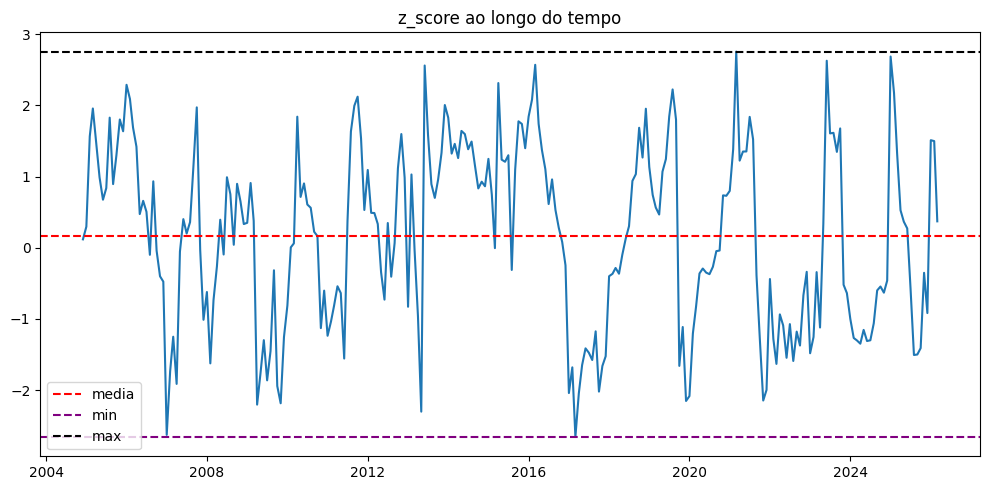

In [35]:
df['shock'] = shock(df['BETA'])


In [36]:
df.loc['2026-01-01':'2026-03-01'][['BETA']]

,BETA
data,
2026-01-01,1.064135
2026-02-01,1.070227
2026-03-01,0.552270


Esses sao os betas dos primeiro trimestre do ano de 2026, onde foi caracterizado pelo clima de tensao no oriente médio e fechamento do estreito de Ormuz

In [37]:
df.isnull().sum()

Produção de derivados de petróleo                       0
Consumo de derivados de petróleo - gasolina             0
Consumo de derivados de petróleo - Óleo combustível     0
Selic                                                   0
Cambio - IPCA                                           0
IPCA                                                    0
Producao Industrial                                     0
Balança comercial                                       0
IBC-Br                                                  0
Close_PETR4.SA                                          0
Volume_PETR4.SA                                         0
Close_IBOV                                              0
BETA                                                   12
shock                                                   0
dtype: int64

In [38]:
df['shock'].value_counts()

shock
0    220
1     59
Name: count, dtype: int64

In [39]:
df = df.dropna()
df

,Produção de derivados de petróleo,Consumo de derivados de petróleo - gasolina,Consumo de derivados de petróleo - Óleo combustível,Selic,Cambio - IPCA,IPCA,Producao Industrial,Balança comercial,IBC-Br,Close_PETR4.SA,Volume_PETR4.SA,Close_IBOV,BETA,shock
data,,,,,,,,,,,,,,
2004-01-01,1457.0,287.000000,91.0,1.27,130.930000,0.76,89.5,1507.1,72.33564,1.841724,987574400,21851.0,0.766782,0
2004-02-01,1452.0,283.000000,90.0,1.08,137.730000,0.61,86.3,1897.7,73.04534,1.929000,812371200,21755.0,0.477635,0
2004-03-01,1480.0,294.000000,100.0,1.38,135.510000,0.47,101.3,2462.5,73.85742,2.011335,768102400,22142.0,0.452186,0
2004-04-01,1449.0,311.000000,96.0,1.18,135.100000,0.37,95.8,1841.5,74.27324,1.757272,777699200,19607.0,0.717028,0
2004-05-01,1421.0,278.000000,84.0,1.23,142.570000,0.51,100.6,2995.7,74.19837,1.688581,971433600,19545.0,0.743727,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-01,3773.0,589.000000,17.0,1.05,122.770000,0.18,103.2,5038.2,109.28228,30.394917,862424100,159072.0,0.284708,0
2025-12-01,4015.0,687.000000,18.0,1.22,125.670000,0.33,93.9,8505.4,109.29356,29.467482,713308800,161125.0,0.033499,0
2026-01-01,3953.0,580.000000,17.0,1.16,123.710000,0.33,95.2,2907.0,110.22869,37.243122,961223500,181364.0,1.064135,1


In [43]:
df.columns

Index(['Produção de derivados de petróleo',
       'Consumo de derivados de petróleo - gasolina',
       'Consumo de derivados de petróleo - Óleo combustível', 'Selic',
       'Cambio - IPCA', 'IPCA', 'Producao Industrial', 'Balança comercial',
       'IBC-Br', 'Close_PETR4.SA', 'Volume_PETR4.SA', 'Close_IBOV', 'BETA',
       'shock', 'event'],
      dtype='object')